# Notebook 1 — Data Collection (Binance BTCUSDT)
**Թեմա:** Նեյրոնային ցանցերի կիրառությունը արժեթղթերի շուկայի վերլուծության համար  
**Տվյալներ:** Binance BTCUSDT tick-by-tick trade execution data  
**Աղբյուր:** Binance Public Data API (data.binance.vision)

## 1. Libraries

In [11]:
# Install required libraries if needed
# !pip install requests pandas numpy tqdm matplotlib seaborn

import os
import io
from io import BytesIO
import zipfile
import requests
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Libraries loaded.')

Libraries loaded.


## 2. Parameters

Binance-ի հրապարակային արխիվից կներբեռնենք BTCUSDT trade տվյալները։  
Ամեն ամիս առանձին zip ֆայլ է — վերցրել եմ **1 ամիս**։

In [12]:
SYMBOL     = "BTCUSDT"
BASE_URL = "https://data.binance.vision/data/spot/daily/trades"

MONTHS = [
    "2024-01-01", "2024-01-02", "2024-01-03",
    "2024-01-04", "2024-01-05", "2024-01-06",
    "2024-01-07", "2024-01-08", "2024-01-09",
    "2024-01-10",
]
output_file = "merged_binance_trades.csv"

os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

print(f'Symbol: {SYMBOL}')
print(f'Months: {MONTHS}')

Symbol: BTCUSDT
Months: ['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08', '2024-01-09', '2024-01-10']


## 3. Download Data from Binance Public Archive

In [18]:
all_dfs = []

for month in MONTHS:
    file_name = f"{SYMBOL}-trades-{month}.zip"
    url       = f"{BASE_URL}/{SYMBOL}/{file_name}"
    print(f"Downloading {file_name} ...")
    try:
        r = requests.get(url, timeout=60)
        if r.status_code != 200:
            print(f"File not found: {file_name}")
            continue
        with zipfile.ZipFile(BytesIO(r.content)) as z:
            csv_file = z.namelist()[0]
            df = pd.read_csv(z.open(csv_file), header=None)
            df.columns = ["trade_id", "price", "qty", "quote_qty",
                          "time", "is_buyer_maker", "is_best_match"]
            all_dfs.append(df)
            print(f"  Loaded: {len(df):,} rows")
    except Exception as e:
        print(f"Error: {file_name}: {e}")

if not all_dfs:
    print("No data was downloaded.")
else:
    print("Merging...")
    merged_df = pd.concat(all_dfs, ignore_index=True)
    merged_df["price"]     = pd.to_numeric(merged_df["price"],     errors="coerce")
    merged_df["qty"]       = pd.to_numeric(merged_df["qty"],       errors="coerce")
    merged_df["quote_qty"] = pd.to_numeric(merged_df["quote_qty"], errors="coerce")
    merged_df["time"]      = pd.to_datetime(merged_df["time"], unit="ms")

    merged_df['side']  = merged_df['is_buyer_maker'].map({False: 'buy', True: 'sell'})
    merged_df['date']  = merged_df['time'].dt.date
    merged_df['hour']  = merged_df['time'].dt.hour
    merged_df['month'] = merged_df['time'].dt.to_period('M').astype(str)

    merged_df.to_csv(output_file, index=False)
    merged_df.to_pickle('data/processed/trades_clean.pkl')
    
    print(f"Saved: {output_file}")
    print(f"Saved: data/processed/trades_clean.pkl")
    print(f"Total rows: {len(merged_df):,}")
    print(merged_df.head())


  Loaded: 1,114,623 rows
  Loaded: 2,247,532 rows
  Loaded: 2,658,041 rows
  Loaded: 1,819,944 rows
  Loaded: 2,064,845 rows
  Loaded: 956,642 rows
  Loaded: 1,109,259 rows
  Loaded: 2,364,464 rows
  Loaded: 2,637,745 rows
  Loaded: 3,133,588 rows
Merging...
Saved: merged_binance_trades.csv
Saved: data/processed/trades_clean.pkl
Total rows: 20,106,683
     trade_id     price      qty  quote_qty                    time  \
0  3344774379  42283.58  0.00069  29.175670 2024-01-01 00:00:00.000   
1  3344774380  42283.59  0.00144  60.888370 2024-01-01 00:00:00.001   
2  3344774381  42283.58  0.00102  43.129252 2024-01-01 00:00:00.003   
3  3344774382  42283.59  0.00219  92.601062 2024-01-01 00:00:00.003   
4  3344774383  42283.59  0.00163  68.922252 2024-01-01 00:00:00.004   

   is_buyer_maker  is_best_match  side        date  hour    month  
0            True           True  sell  2024-01-01     0  2024-01  
1           False           True   buy  2024-01-01     0  2024-01  
2            Tr

In [21]:
merged_df.head()

,trade_id,price,qty,quote_qty,time,is_buyer_maker,is_best_match,side,date,hour,month
0,3344774379,42283.58,0.00069,29.175670,2024-01-01 00:00:00.000,True,True,sell,2024-01-01,0,2024-01
1,3344774380,42283.59,0.00144,60.888370,2024-01-01 00:00:00.001,False,True,buy,2024-01-01,0,2024-01
2,3344774381,42283.58,0.00102,43.129252,2024-01-01 00:00:00.003,True,True,sell,2024-01-01,0,2024-01
3,3344774382,42283.59,0.00219,92.601062,2024-01-01 00:00:00.003,False,True,buy,2024-01-01,0,2024-01
4,3344774383,42283.59,0.00163,68.922252,2024-01-01 00:00:00.004,False,True,buy,2024-01-01,0,2024-01


## 4. Data Preprocessing

In [22]:
# Sort by time
merged_df = merged_df.sort_values('time').reset_index(drop=True)

# is_best_match type
merged_df['is_best_match'] = merged_df['is_best_match'].astype(bool)

print(f'Date range: {merged_df["time"].min()} → {merged_df["time"].max()}')
print(f'Total trades: {len(merged_df):,}')
print(f'\nData types:')
print(merged_df.dtypes)
print(f'\nNull values:')
print(merged_df.isnull().sum())

Date range: 2024-01-01 00:00:00 → 2024-01-10 23:59:59.999000
Total trades: 20,106,683

Data types:
trade_id                   int64
price                    float64
qty                      float64
quote_qty                float64
time              datetime64[ns]
is_buyer_maker              bool
is_best_match               bool
side                      object
date                      object
hour                       int32
month                     object
dtype: object

Null values:
trade_id          0
price             0
qty               0
quote_qty         0
time              0
is_buyer_maker    0
is_best_match     0
side              0
date              0
hour              0
month             0
dtype: int64


## 5. Basic Statistics

In [23]:
print('=== BASIC STATISTICS ===')
print(df[['price', 'qty', 'quote_qty']].describe().round(4))
print(f'\nBuy trades:  {(df["side"]=="buy").sum():,} ({(df["side"]=="buy").mean()*100:.2f}%)')
print(f'Sell trades: {(df["side"]=="sell").sum():,} ({(df["side"]=="sell").mean()*100:.2f}%)')
print(f'Best match:  {df["is_best_match"].sum():,} ({df["is_best_match"].mean()*100:.2f}%)')

=== BASIC STATISTICS ===
              price           qty     quote_qty
count  2.010668e+07  2.010668e+07  2.010668e+07
mean   4.464749e+04  2.700000e-02  1.207924e+03
std    1.368991e+03  1.298000e-01  5.820150e+03
min    4.075000e+04  0.000000e+00  4.081000e-01
25%    4.365986e+04  5.000000e-04  2.470970e+01
50%    4.462402e+04  1.300000e-03  5.602350e+01
75%    4.566247e+04  1.000000e-02  4.413240e+02
max    4.797200e+04  1.197397e+02  5.508026e+06

Buy trades:  9,188,983 (45.70%)
Sell trades: 10,917,700 (54.30%)
Best match:  20,106,683 (100.00%)


## 6. Save Processed Data

In [24]:
merged_df.to_pickle('data/processed/trades_clean.pkl')
merged_df.head(10000).to_csv('data/processed/trades_sample.csv', index=False)

print(f'Saved: data/processed/trades_clean.pkl ({len(merged_df):,} rows)')
print(f'Saved: data/processed/trades_sample.csv (10,000 rows)')

Saved: data/processed/trades_clean.pkl (20,106,683 rows)
Saved: data/processed/trades_sample.csv (10,000 rows)


## 7. Quick Overview Plots

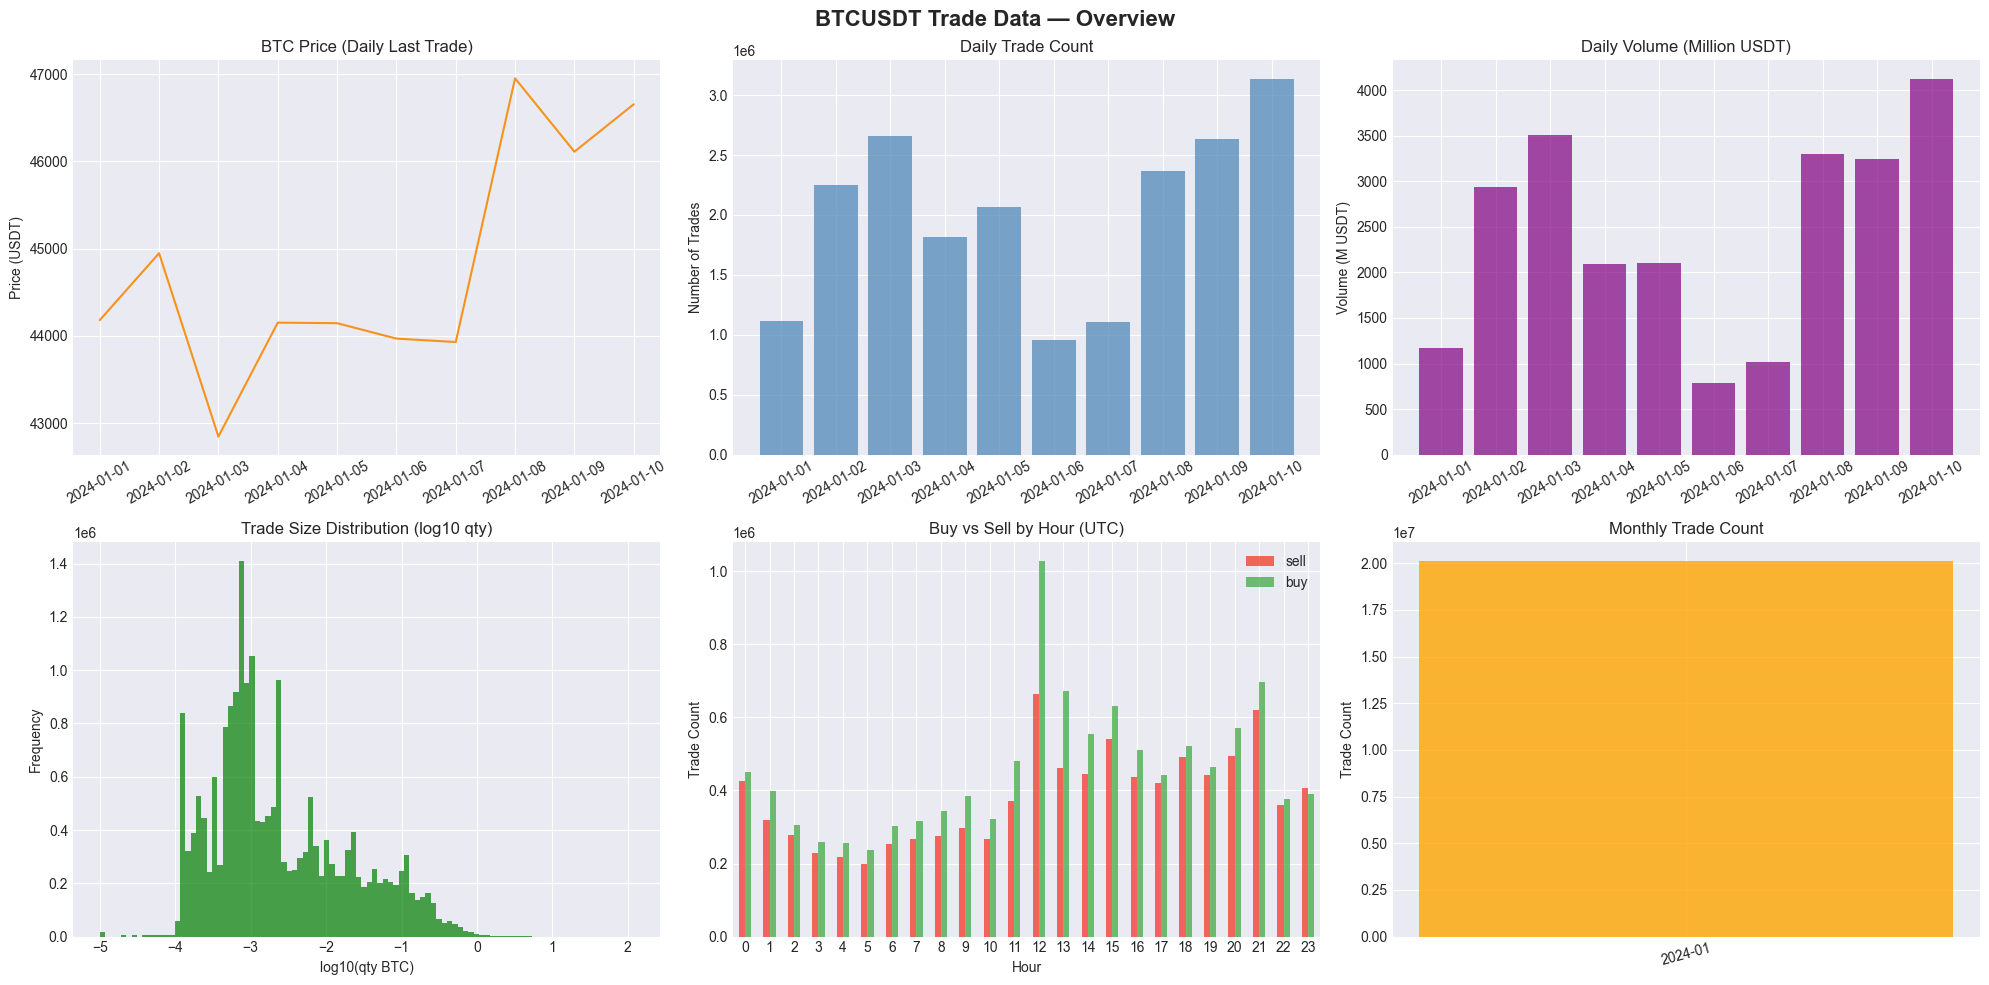

Plot saved.


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('BTCUSDT Trade Data — Overview', fontsize=16, fontweight='bold')

# 1. Daily close price
daily_price = merged_df.groupby('date')['price'].last()
axes[0,0].plot(daily_price.index, daily_price.values, color='#F7931A', linewidth=1.5)
axes[0,0].set_title('BTC Price (Daily Last Trade)')
axes[0,0].set_ylabel('Price (USDT)')
axes[0,0].tick_params(axis='x', rotation=30)

# 2. Daily trade count
daily_count = merged_df.groupby('date').size()
axes[0,1].bar(daily_count.index, daily_count.values, color='steelblue', alpha=0.7, width=0.8)
axes[0,1].set_title('Daily Trade Count')
axes[0,1].set_ylabel('Number of Trades')
axes[0,1].tick_params(axis='x', rotation=30)

# 3. Daily volume (quote_qty)
daily_vol = merged_df.groupby('date')['quote_qty'].sum() / 1e6
axes[0,2].bar(daily_vol.index, daily_vol.values, color='purple', alpha=0.7, width=0.8)
axes[0,2].set_title('Daily Volume (Million USDT)')
axes[0,2].set_ylabel('Volume (M USDT)')
axes[0,2].tick_params(axis='x', rotation=30)

# 4. Trade size distribution
axes[1,0].hist(np.log10(merged_df['qty'] + 1e-9), bins=100, color='green', alpha=0.7)
axes[1,0].set_title('Trade Size Distribution (log10 qty)')
axes[1,0].set_xlabel('log10(qty BTC)')
axes[1,0].set_ylabel('Frequency')

# 5. Buy vs Sell by hour
hourly = merged_df.groupby(['hour', 'side']).size().unstack(fill_value=0)
hourly.plot(kind='bar', ax=axes[1,1], color=['#F44336','#4CAF50'], alpha=0.8)
axes[1,1].set_title('Buy vs Sell by Hour (UTC)')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Trade Count')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(['sell', 'buy'])

# 6. Monthly trade count
monthly = merged_df.groupby('month').size()
axes[1,2].bar([str(m) for m in monthly.index], monthly.values, color='orange', alpha=0.8)
axes[1,2].set_title('Monthly Trade Count')
axes[1,2].set_ylabel('Trade Count')
axes[1,2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('data/processed/01_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

**Հաջորդ → Notebook 2: EDA + Behavioral Visualizations**